## 1. Import Libraries and Reduce Dataset

In [1]:
import pandas as pd
import numpy as np

# 1. Load the data 
df = pd.read_csv("US_Accidents_March23.csv")

# 2. Force the sample (This replaces the old df entirely)
# This says: For every state, take up to 1000 rows. 
df_balanced = df.groupby('State').head(1000).reset_index(drop=True)

# 3. VERIFY 
print(f"New Total Rows: {len(df_balanced)}")
print("Rows per State:")
print(df_balanced['State'].value_counts().head(10))


New Total Rows: 48215
Rows per State:
State
OH    1000
WV    1000
CA    1000
FL    1000
GA    1000
SC    1000
NE    1000
IA    1000
IL    1000
MO    1000
Name: count, dtype: int64


Pandas is used to load and manipulate datasets, while NumPy helps with numerical operations.


## 2. Load the dataset

In [2]:
# Save the balanced data as a new file
df_balanced.to_csv("Raw_Data(N).csv", index=False)


In [3]:
# Display the first 5 rows
df_balanced.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


This next step loads the dataset and allows us to preview the first few rows to understand its structure.

## 3. Explore the Dtaset Structure

In [5]:
df_balanced.info()# Check the dataset structure
print(df_balanced)

<class 'pandas.DataFrame'>
RangeIndex: 48215 entries, 0 to 48214
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     48215 non-null  str    
 1   Source                 48215 non-null  str    
 2   Severity               48215 non-null  int64  
 3   Start_Time             48215 non-null  str    
 4   End_Time               48215 non-null  str    
 5   Start_Lat              48215 non-null  float64
 6   Start_Lng              48215 non-null  float64
 7   End_Lat                5218 non-null   float64
 8   End_Lng                5218 non-null   float64
 9   Distance(mi)           48215 non-null  float64
 10  Description            48215 non-null  str    
 11  Street                 48093 non-null  str    
 12  City                   48212 non-null  str    
 13  County                 48215 non-null  str    
 14  State                  48215 non-null  str    
 15  Zipcode      

This shows the column names, number of rows and  data types 

## 4. Summary statistics

In [6]:
df_balanced.describe()
# Get summary statistics for numerical columns

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,48215.000000,48215.000000,48215.000000,5218.000000,5218.000000,48215.000000,47236.000000,34261.000000,47187.000000,47304.000000,46671.000000,43492.000000,27556.000000
mean,2.273608,39.363852,-90.650908,44.125880,-98.215917,0.576748,54.605062,49.154385,67.419183,29.140536,8.806047,8.275490,0.020700
std,0.672029,4.513199,15.096757,2.770887,15.682616,3.009524,23.058766,28.337361,22.380374,1.696647,2.683868,5.487759,0.322223
min,1.000000,25.484524,-124.497414,37.264501,-117.041662,0.000000,-36.000000,-53.000000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,36.075361,-97.618877,42.397430,-111.046440,0.000000,36.000000,27.400000,51.000000,29.130000,10.000000,5.000000,0.000000
50%,2.000000,39.766964,-87.935402,44.036292,-103.148523,0.000000,55.000000,46.000000,71.000000,29.830000,10.000000,7.000000,0.000000
75%,3.000000,42.319462,-77.219921,46.804749,-81.785960,0.010000,74.000000,74.000000,87.000000,30.050000,10.000000,11.500000,0.000000
max,4.000000,49.000580,-67.113167,49.075000,-67.109242,115.379997,115.000000,115.000000,100.000000,30.870000,50.000000,66.700000,10.140000


This helps us understand the summary distribution of numeric variables such as temperature, humidity and visibility

## 5. Check for Missing Values

In [7]:
# Count missing values in each column
df_balanced.isnull().sum()

ID                           0
Source                       0
Severity                     0
Start_Time                   0
End_Time                     0
Start_Lat                    0
Start_Lng                    0
End_Lat                  42997
End_Lng                  42997
Distance(mi)                 0
Description                  0
Street                     122
City                         3
County                       0
State                        0
Zipcode                      4
Country                      0
Timezone                    20
Airport_Code                58
Weather_Timestamp          458
Temperature(F)             979
Wind_Chill(F)            13954
Humidity(%)               1028
Pressure(in)               911
Visibility(mi)            1544
Wind_Direction             694
Wind_Speed(mph)           4723
Precipitation(in)        20659
Weather_Condition         1452
Amenity                      0
Bump                         0
Crossing                     0
Give_Way

## 6. Remove the duplicates

In [8]:
# Check for duplicate rows
df_balanced.duplicated().sum()

# Remove duplicates
df_balanced = df_balanced.drop_duplicates()

Duplicate rows can distort the results of analysis, so they must be removed.

## 7. convert Date column

In [9]:
#Convert date column

df_balanced['Start_Time'] = pd.to_datetime(df_balanced['Start_Time'], format='mixed')

This allows us to perform time-based analysis such as extracting year, month, and hour.

## 8. Create useful time columns

In [10]:
# Extract useful time features
df_balanced['Year'] = df_balanced['Start_Time'].dt.year
df_balanced['Month'] = df_balanced['Start_Time'].dt.month
df_balanced['Hour'] = df_balanced['Start_Time'].dt.hour

These columns help analyze accident trends by year, month, and hour of the day.

## 9. Verify the Cleaned Dataset

In [11]:
df_balanced.shape
print(df_balanced.shape)

(48215, 49)


## 10. Save the Cleaned Dataset

In [12]:
# Save the cleaned dataset
df_balanced.to_csv("cleaned_data.csv", index=False)

### Exploratory Data Analysis (EDA)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_balanced = pd.read_csv("cleaned_data.csv")

Although a balanced dataset with 1,000 samples per state was created to ensure equal representation, it was found to be less suitable for certain types of analysis. This is because limiting each state to the same number of observations removes the natural differences in accident frequency across states.

the original cleaned dataset containing approximately 8.7 million records was used for analyses that required an accurate representation of accident distribution across states. 

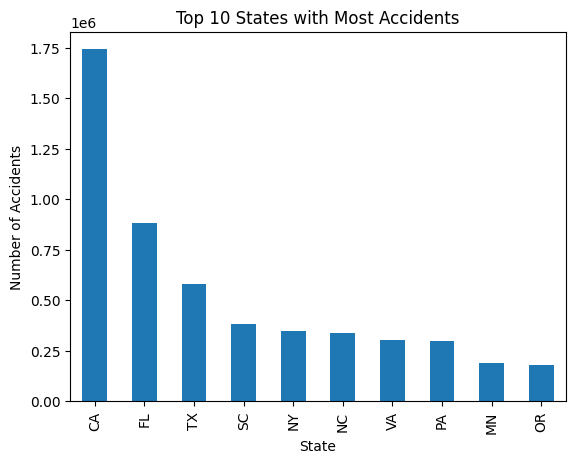

In [14]:
df['State'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 States with Most Accidents")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.show()

## Accidents by Hour of the Day

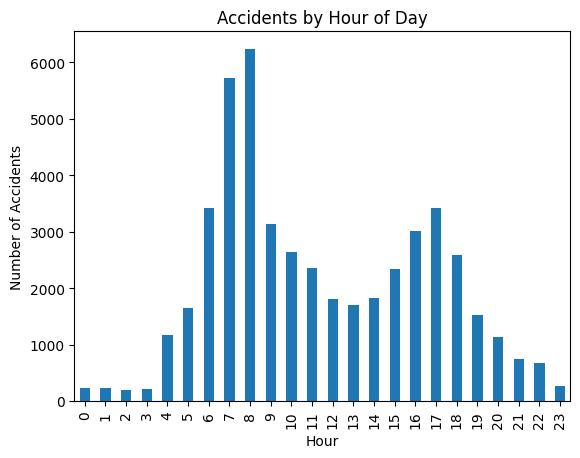

In [15]:
df_balanced['Hour'].value_counts().sort_index().plot(kind='bar')

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

In [ ]:
#line plot 
hour_counts = df_balanced['Hour'].value_counts().sort_index()

sns.lineplot(x=hour_counts.index, y=hour_counts.values)

plt.title("Accidents by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()



This charts shows what time of day accidents happen most often.

Accidents are often highest during rush hours, when traffic is heavy whic is in the morning and in the evening

## Accident Severity Distribution

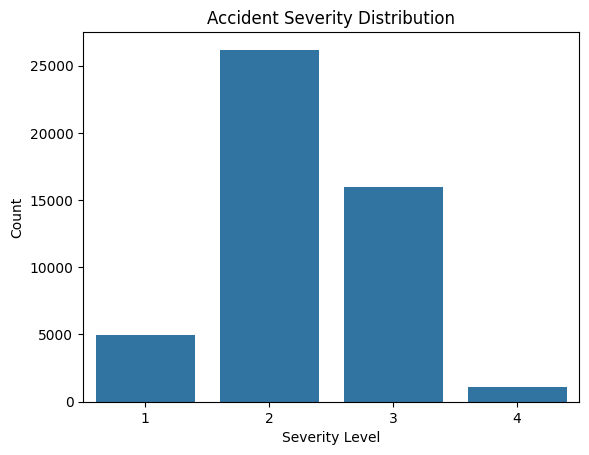

In [16]:
sns.countplot(x='Severity', data=df_balanced)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

This shows how severe accidents usually are.


Most accidents tend to fall within lower severity levels, while very severe accidents are less common.

## Accidents by Month

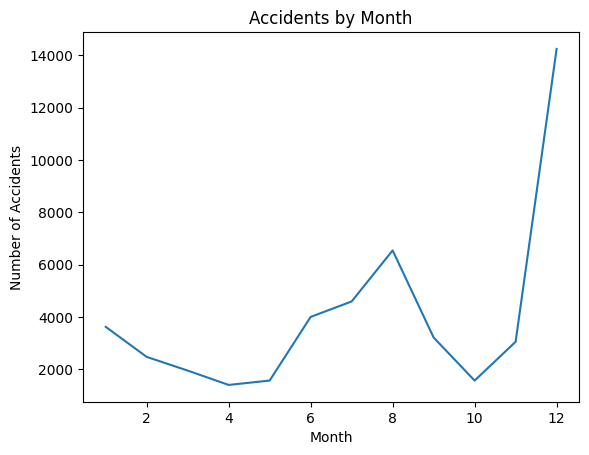

In [17]:
df_balanced['Month'].value_counts().sort_index().plot(kind='line')

plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

This chart shows how accidents change throughout the year.


Certain months may show higher accident rates due to weather conditions or holiday travel.

## Weather Conditions and Accidents

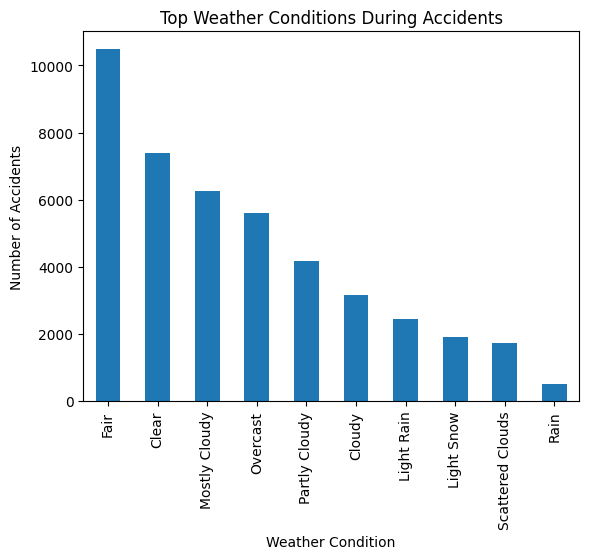

In [18]:
df_balanced['Weather_Condition'].value_counts().head(10).plot(kind='bar')

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.show()

This shows the most common weather conditions when accidents occur.


Many accidents occur during clear weather, but conditions like rain or fog can also contribute to accidents.

## Advanced Analysis & Insight Generation

## 1. Advanced Analysis

This part shows a deeper look into the data, not just basic charts.

## A. Accident Severity by Weather

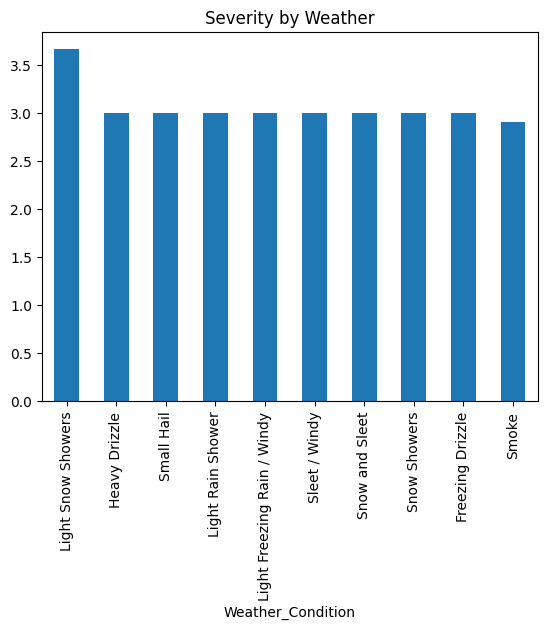

In [22]:
df_balanced.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Severity by Weather")
plt.show()

The relationship between weather conditions and accident severity shows that adverse weather conditions such as rain, fog, or low visibility are associated with more severe accidents. Poor weather reduces visibility and road traction, increasing the likelihood of more serious collisions.

## A. Accident Severity by Day

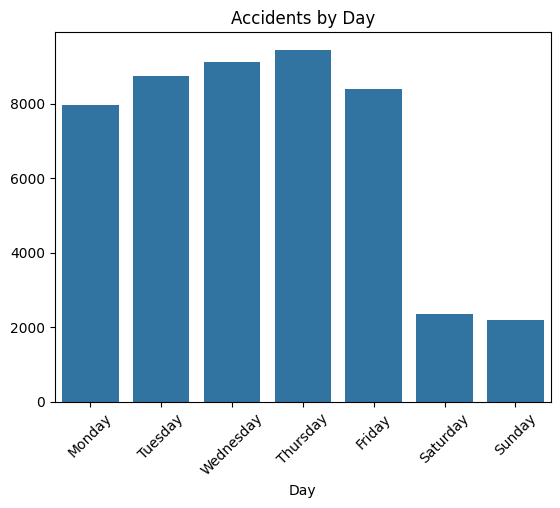

In [30]:
# ensure a Day column exists from Start_Time first
# ensure Start_Time is datetime before using .dt
df_balanced['Start_Time'] = pd.to_datetime(df_balanced['Start_Time'], errors='coerce')
df_balanced['Day'] = df_balanced['Start_Time'].dt.day_name()

# then count by day of week
day_counts = df_balanced['Day'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    fill_value=0
)

sns.barplot(x=day_counts.index, y=day_counts.values)
plt.xticks(rotation=45)
plt.title("Accidents by Day")
plt.show()

# then count by day of week
day_counts = df_balanced['Day'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    fill_value=0
)



The variation in accident severity across different days of the week indicates that human activity patterns play a role in accident outcomes. Weekdays tend to have higher accident occurrences due to commuting, while differences in severity may be influenced by traffic conditions, driver behavior, and travel patterns.

## A. Accident Severity by Hour

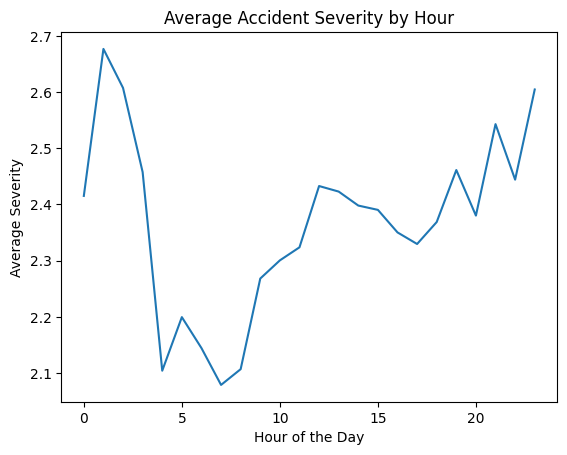

In [18]:
# Analyze how accident severity changes by hour
df_balanced.groupby('Hour')['Severity'].mean().plot(kind='line')

import matplotlib.pyplot as plt
plt.title("Average Accident Severity by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Severity")
plt.show()

This chart shows how accident severity varies throughout the day, indicating that certain hours may be associated with more dangerous driving conditions.
Accidents peak during rush hours due to heavy traffic.

## Accidents by State and Severity

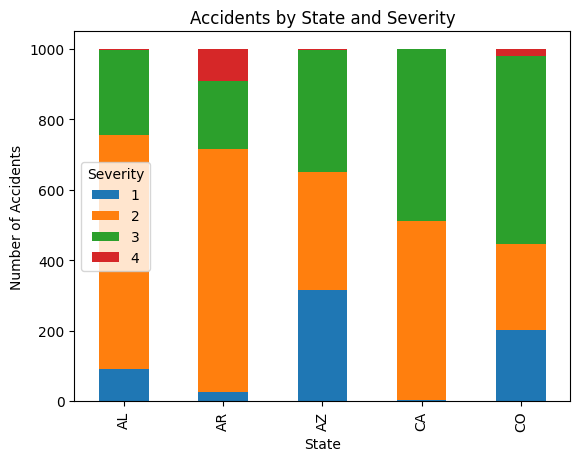

In [19]:
# Compare accident counts by state and severity
pd.crosstab(df_balanced['State'], df_balanced['Severity']).head().plot(kind='bar', stacked=True)

plt.title("Accidents by State and Severity")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.show()

The analysis of accidents by state and severity reveals that not only do accident frequencies vary by location, but the severity levels also differ across states. Some states experience a higher proportion of severe accidents, which may be influenced by factors such as road conditions, traffic density, and infrastructure quality.